In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 100

print('Setup complete ')

Setup complete 


In [3]:
BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / 'data' / 'processed'
OUT_DIR  = BASE_DIR / 'data' / 'processed'

nav   = pd.read_csv(PROC_DIR / 'clean_nav.csv',          parse_dates=['date'])
fund  = pd.read_csv(PROC_DIR / 'clean_fund_master.csv')
perf  = pd.read_csv(PROC_DIR / 'clean_performance.csv')
bench = pd.read_csv(PROC_DIR / 'clean_benchmark_indices.csv', parse_dates=['date'])

nav_named = nav.merge(fund[['amfi_code','scheme_name','fund_house',
                             'expense_ratio_pct','risk_category']], 
                      on='amfi_code', how='left')

print(f'NAV rows     : {len(nav):,}')
print(f'Funds        : {nav["amfi_code"].nunique()}')
print(f'Benchmark rows: {len(bench):,}')
print('All data loaded ')

NAV rows     : 64,320
Funds        : 40
Benchmark rows: 8,050
All data loaded 


Daily Return Statistics:
count    64280.0000
mean         0.0005
std          0.0087
min         -0.0581
25%         -0.0021
50%          0.0000
75%          0.0032
max          0.0647
Name: daily_return, dtype: float64


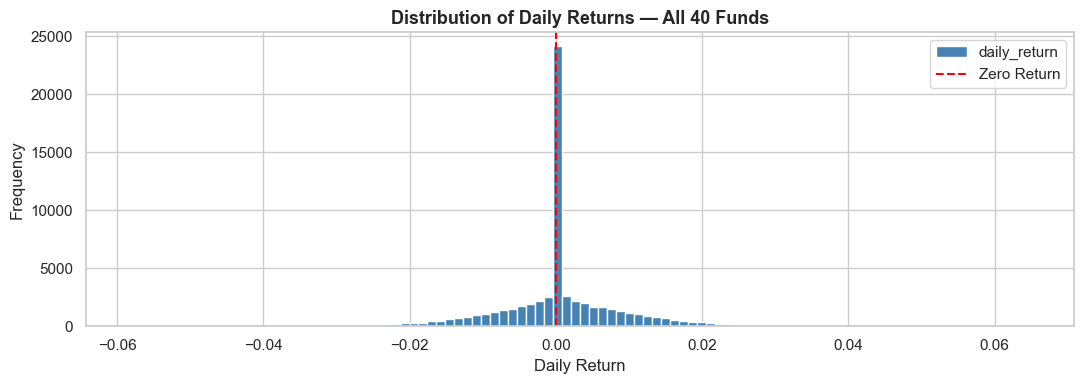

Daily returns computed 


In [5]:
# Compute daily returns for all 40 funds
nav_sorted = nav_named.sort_values(['amfi_code','date'])
nav_sorted['daily_return'] = (nav_sorted.groupby('amfi_code')['nav']
                               .pct_change())

# Validate distribution
print("Daily Return Statistics:")
print(nav_sorted['daily_return'].describe().round(4))

# Plot distribution
fig, ax = plt.subplots(figsize=(11, 4))
nav_sorted['daily_return'].dropna().plot.hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Daily Returns — All 40 Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Frequency')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Return')
ax.legend()
plt.tight_layout()
plt.show()

print('Daily returns computed ')

In [7]:
# Compute CAGR for each fund
def compute_cagr(group, years):
    end_date   = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    subset     = group[group['date'] >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_start = subset.iloc[0]['nav']
    nav_end   = subset.iloc[-1]['nav']
    n_days    = (subset.iloc[-1]['date'] - subset.iloc[0]['date']).days
    n_years   = n_days / 365.25
    if n_years <= 0 or nav_start <= 0:
        return np.nan
    return ((nav_end / nav_start) ** (1 / n_years) - 1) * 100

cagr_results = []
for code, group in nav_sorted.groupby('amfi_code'):
    name     = group['scheme_name'].iloc[0]
    house    = group['fund_house'].iloc[0]
    cagr_1yr = compute_cagr(group, 1)
    cagr_3yr = compute_cagr(group, 3)
    cagr_5yr = compute_cagr(group, 5)
    cagr_results.append({
        'amfi_code'   : code,
        'scheme_name' : name,
        'fund_house'  : house,
        'cagr_1yr_pct': round(cagr_1yr, 2),
        'cagr_3yr_pct': round(cagr_3yr, 2),
        'cagr_5yr_pct': round(cagr_5yr, 2),
    })

cagr_df = pd.DataFrame(cagr_results)
print(cagr_df[['scheme_name','cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_pct']].to_string())
print('\nCAGR computed ')

                                              scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0               HDFC Top 100 Fund - Regular Plan - Growth         -2.23          1.29          2.64
1            HDFC Short Term Debt Fund - Regular - Growth          3.71          3.92          4.46
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.28         32.43         30.12
3           ABSL Frontline Equity Fund - Regular - Growth         47.96         28.96         23.54
4                  ABSL Small Cap Fund - Regular - Growth        -24.00         -4.15          7.94
5                     ABSL Liquid Fund - Regular - Growth          7.24          6.31          6.51
6              UTI Nifty 50 Index Fund - Regular - Growth         20.22         19.66         18.23
7                     UTI Mid Cap Fund - Regular - Growth        -16.81         -0.77          1.17
8                   UTI Flexi Cap Fund - Regular - Growth         13.59         25.55         16.84


In [9]:
# Sharpe Ratio = (Rp - Rf) / Std(Rp) * sqrt(252)
RF = 6.5 / 100  # RBI repo rate proxy

sharpe_results = []
for code, group in nav_sorted.groupby('amfi_code'):
    name    = group['scheme_name'].iloc[0]
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    rf_daily     = RF / 252
    excess       = returns - rf_daily
    sharpe       = (excess.mean() / excess.std()) * np.sqrt(252)
    sharpe_results.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'sharpe_ratio': round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results).sort_values('sharpe_ratio', ascending=False)
sharpe_df['sharpe_rank'] = range(1, len(sharpe_df)+1)

print("Top 10 Funds by Sharpe Ratio:")
print(sharpe_df.head(10)[['scheme_name','sharpe_ratio','sharpe_rank']].to_string())
print('\nSharpe ratio computed ')

Top 10 Funds by Sharpe Ratio:
                                           scheme_name  sharpe_ratio  sharpe_rank
34       Mirae Asset Large Cap Fund - Regular - Growth        1.0682            1
30              Kotak Flexicap Fund - Regular - Growth        0.9656            2
36       Mirae Asset Tax Saver Fund - Regular - Growth        0.9190            3
25            ICICI Pru Midcap Fund - Regular - Growth        0.8833            4
19           SBI Bluechip Fund - Regular Plan - Growth        0.8610            5
38                  DSP Midcap Fund - Regular - Growth        0.8329            6
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083            7
9       Nippon India Large Cap Fund - Regular - Growth        0.7589            8
16                 Axis Midcap Fund - Regular - Growth        0.7305            9
3        ABSL Frontline Equity Fund - Regular - Growth        0.7174           10

Sharpe ratio computed 


In [10]:
# Sortino Ratio = (Rp - Rf) / Downside_Std * sqrt(252)
sortino_results = []
for code, group in nav_sorted.groupby('amfi_code'):
    name    = group['scheme_name'].iloc[0]
    returns = group['daily_return'].dropna()
    if len(returns) < 30:
        continue
    rf_daily      = RF / 252
    excess        = returns - rf_daily
    downside      = excess[excess < 0]
    downside_std  = downside.std()
    if downside_std == 0:
        continue
    sortino = (excess.mean() / downside_std) * np.sqrt(252)
    sortino_results.append({
        'amfi_code'   : code,
        'scheme_name' : name,
        'sortino_ratio': round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results).sort_values('sortino_ratio', ascending=False)

print("Top 10 Funds by Sortino Ratio:")
print(sortino_df.head(10)[['scheme_name','sortino_ratio']].to_string())
print('\nSortino ratio computed ')

Top 10 Funds by Sortino Ratio:
                                           scheme_name  sortino_ratio
34       Mirae Asset Large Cap Fund - Regular - Growth         1.5548
30              Kotak Flexicap Fund - Regular - Growth         1.4859
36       Mirae Asset Tax Saver Fund - Regular - Growth         1.3870
25            ICICI Pru Midcap Fund - Regular - Growth         1.3211
19           SBI Bluechip Fund - Regular Plan - Growth         1.3025
38                  DSP Midcap Fund - Regular - Growth         1.2018
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1844
9       Nippon India Large Cap Fund - Regular - Growth         1.1215
16                 Axis Midcap Fund - Regular - Growth         1.0915
3        ABSL Frontline Equity Fund - Regular - Growth         1.0788

Sortino ratio computed 


In [11]:
# Alpha & Beta using OLS regression vs Nifty 100
nifty100 = bench[bench['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()

alpha_beta_results = []
for code, group in nav_sorted.groupby('amfi_code'):
    name    = group['scheme_name'].iloc[0]
    house   = group['fund_house'].iloc[0]
    merged  = group[['date','daily_return']].merge(
                nifty100[['date','bench_return']], on='date', how='inner')
    merged  = merged.dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['bench_return'], merged['daily_return'])
    alpha = intercept * 252 * 100
    beta  = slope
    alpha_beta_results.append({
        'amfi_code'  : code,
        'scheme_name': name,
        'fund_house' : house,
        'alpha'      : round(alpha, 4),
        'beta'       : round(beta, 4),
        'r_squared'  : round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.to_csv(OUT_DIR / 'alpha_beta.csv', index=False)
print("Alpha Beta Table:")
print(alpha_beta_df[['scheme_name','alpha','beta','r_squared']].to_string())
print('\nalpha_beta.csv saved ')

Alpha Beta Table:
                                              scheme_name    alpha    beta  r_squared
0               HDFC Top 100 Fund - Regular Plan - Growth   3.7476 -0.0583     0.0027
1            HDFC Short Term Debt Fund - Regular - Growth   4.2818  0.0012     0.0000
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth  27.1954  0.0051     0.0000
3           ABSL Frontline Equity Fund - Regular - Growth  21.3998  0.0211     0.0003
4                  ABSL Small Cap Fund - Regular - Growth  10.8971 -0.0653     0.0011
5                     ABSL Liquid Fund - Regular - Growth   6.0861  0.0003     0.0000
6              UTI Nifty 50 Index Fund - Regular - Growth  17.0488 -0.0195     0.0004
7                     UTI Mid Cap Fund - Regular - Growth   2.8969 -0.0421     0.0009
8                   UTI Flexi Cap Fund - Regular - Growth  16.2113  0.0167     0.0002
9          Nippon India Large Cap Fund - Regular - Growth  21.8294 -0.0084     0.0001
10          Nippon India Large Cap F

In [12]:
# Maximum Drawdown = min(NAV / running_max - 1)
drawdown_results = []
for code, group in nav_sorted.groupby('amfi_code'):
    name        = group['scheme_name'].iloc[0]
    group       = group.sort_values('date')
    rolling_max = group['nav'].cummax()
    drawdown    = (group['nav'] / rolling_max - 1)
    max_dd      = drawdown.min()
    worst_date  = group.loc[drawdown.idxmin(), 'date']
    drawdown_results.append({
        'amfi_code'       : code,
        'scheme_name'     : name,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'worst_date'      : worst_date
    })

drawdown_df = pd.DataFrame(drawdown_results).sort_values('max_drawdown_pct')

print("Top 10 Worst Drawdowns:")
print(drawdown_df.head(10)[['scheme_name','max_drawdown_pct','worst_date']].to_string())
print('\nMax drawdown computed ')

Top 10 Worst Drawdowns:
                                       scheme_name  max_drawdown_pct worst_date
22       SBI Small Cap Fund - Direct Plan - Growth            -52.57 2025-10-28
17          Axis Small Cap Fund - Regular - Growth            -51.68 2026-05-11
4           ABSL Small Cap Fund - Regular - Growth            -35.45 2026-05-11
39           DSP Small Cap Fund - Regular - Growth            -31.17 2025-01-03
21      SBI Small Cap Fund - Regular Plan - Growth            -28.71 2025-05-14
7              UTI Mid Cap Fund - Regular - Growth            -28.00 2026-04-27
0        HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-09-15
29   Kotak Emerging Equity Fund - Regular - Growth            -24.00 2024-10-17
11  Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-02-20
15            Axis Bluechip Fund - Direct - Growth            -21.75 2023-05-22

Max drawdown computed 


In [13]:
# Fund Scorecard (0-100)
scorecard = cagr_df[['amfi_code','scheme_name','fund_house','cagr_3yr_pct']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code','sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code','alpha','beta']], on='amfi_code', how='left')
scorecard = scorecard.merge(drawdown_df[['amfi_code','max_drawdown_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(fund[['amfi_code','expense_ratio_pct']], on='amfi_code', how='left')
scorecard = scorecard.dropna()

# Rank each metric
n = len(scorecard)
scorecard['rank_3yr']     = scorecard['cagr_3yr_pct'].rank(ascending=True)
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['rank_alpha']   = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False)
scorecard['rank_maxdd']   = scorecard['max_drawdown_pct'].rank(ascending=False)

# Composite score
scorecard['score'] = (
    0.30 * scorecard['rank_3yr']     +
    0.25 * scorecard['rank_sharpe']  +
    0.20 * scorecard['rank_alpha']   +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_maxdd']
)

# Normalise to 0-100
scorecard['score_100'] = ((scorecard['score'] - scorecard['score'].min()) /
                          (scorecard['score'].max() - scorecard['score'].min()) * 100).round(1)

scorecard = scorecard.sort_values('score_100', ascending=False).reset_index(drop=True)
scorecard['final_rank'] = range(1, len(scorecard)+1)

scorecard.to_csv(OUT_DIR / 'fund_scorecard.csv', index=False)
print("Top 10 Funds by Scorecard:")
print(scorecard[['scheme_name','score_100','final_rank']].head(10).to_string())
print('\nfund_scorecard.csv saved ')

Top 10 Funds by Scorecard:
                                          scheme_name  score_100  final_rank
0            ICICI Pru Midcap Fund - Regular - Growth      100.0           1
1                 Axis Midcap Fund - Regular - Growth       95.2           2
2  HDFC Mid-Cap Opportunities Fund - Regular - Growth       92.9           3
3       Mirae Asset Large Cap Fund - Regular - Growth       92.1           4
4              Kotak Flexicap Fund - Regular - Growth       89.4           5
5          SBI Small Cap Fund - Regular Plan - Growth       85.5           6
6               DSP Small Cap Fund - Regular - Growth       85.2           7
7           ICICI Pru Bluechip Fund - Direct - Growth       84.5           8
8       Mirae Asset Tax Saver Fund - Regular - Growth       82.7           9
9           SBI Bluechip Fund - Regular Plan - Growth       80.4          10

fund_scorecard.csv saved 


FileNotFoundError: [Errno 2] No such file or directory: 'P:\\bluestock_mf_capstone\\bluestock_mf_capstone\\reports\\benchmark_chart.png'

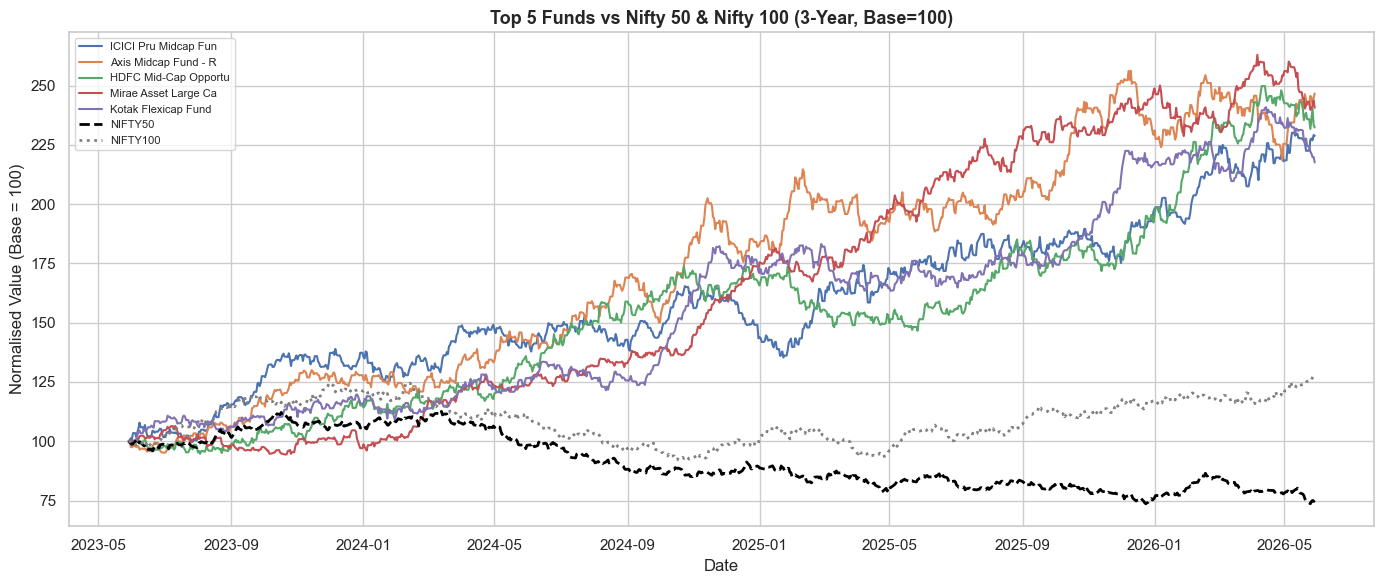

In [14]:
# Benchmark comparison — Top 5 funds vs Nifty 50 and Nifty 100
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)[['amfi_code','scheme_name']].set_index('amfi_code')['scheme_name'].to_dict()

cutoff = nav_sorted['date'].max() - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot top 5 funds (normalised to 100)
for code in top5_codes:
    fund_nav = nav_sorted[(nav_sorted['amfi_code'] == code) &
                          (nav_sorted['date'] >= cutoff)].copy()
    fund_nav = fund_nav.sort_values('date')
    fund_nav['normalised'] = fund_nav['nav'] / fund_nav['nav'].iloc[0] * 100
    ax.plot(fund_nav['date'], fund_nav['normalised'],
            label=top5_names[code][:20], linewidth=1.5)

# Plot Nifty 50
for idx_name, color, style in [('NIFTY50','black','--'), ('NIFTY100','gray',':')]:
    b = bench[(bench['index_name'] == idx_name) &
              (bench['date'] >= cutoff)].sort_values('date')
    b['normalised'] = b['close_value'] / b['close_value'].iloc[0] * 100
    ax.plot(b['date'], b['normalised'], label=idx_name,
            color=color, linestyle=style, linewidth=2)

ax.set_title('Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year, Base=100)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Value (Base = 100)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'benchmark_chart.png', dpi=150)
plt.show()

# Tracking Error
print("\nTracking Error vs Nifty 100:")
nifty100_ret = nifty100.set_index('date')['bench_return']
for code in top5_codes:
    fund_ret = (nav_sorted[nav_sorted['amfi_code'] == code]
                .set_index('date')['daily_return'])
    merged   = pd.concat([fund_ret, nifty100_ret], axis=1).dropna()
    merged.columns = ['fund','bench']
    te = (merged['fund'] - merged['bench']).std() * np.sqrt(252) * 100
    print(f"  {top5_names[code][:30]} : {te:.2f}%")

print('\nBenchmark chart saved ')

In [ ]:
print("=" * 50)
print("DAY 4 PERFORMANCE ANALYTICS COMPLETE")
print("=" * 50)
print(f"Daily returns computed  : {len(nav_sorted):,} rows")
print(f"CAGR computed           : {len(cagr_df)} funds")
print(f"Sharpe ratio computed   : {len(sharpe_df)} funds")
print(f"Sortino ratio computed  : {len(sortino_df)} funds")
print(f"Alpha/Beta computed     : {len(alpha_beta_df)} funds")
print(f"Max Drawdown computed   : {len(drawdown_df)} funds")
print(f"Fund Scorecard saved    : fund_scorecard.csv")
print(f"Alpha Beta saved        : alpha_beta.csv")
print(f"Benchmark chart saved   : benchmark_chart.png")
print("=" * 50)